In [2]:
import pandas as pd
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# Check for issues first
print(df['TotalCharges'].dtype)
print(df.isnull().sum())

str
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].isnull().sum())  # now the real blanks show up as NaN

11


In [6]:
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

C:\Users\Rehan Ahmed\AppData\Local\Temp\ipykernel_4348\2840544469.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [7]:
df.drop('customerID', axis=1, inplace=True)

In [8]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [9]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(cat_cols)
print(len(cat_cols))

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
15


C:\Users\Rehan Ahmed\AppData\Local\Temp\ipykernel_4348\2371146155.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


In [10]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print(df_encoded.shape)
df_encoded.head()

(7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [11]:
df_encoded.dtypes.value_counts()

bool       26
int64       3
float64     2
Name: count, dtype: int64

In [12]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5634, 30)
Test shape: (1409, 30)


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
#Model Training
#Cell 1 — Logistic Regression 

# Check 1: any NaNs left in X_train?
print("NaNs in X_train:", X_train.isnull().sum().sum())
print("NaNs in y_train:", y_train.isnull().sum())

# Check 2: any weird dtypes?
print(X_train.dtypes.value_counts())

NaNs in X_train: 8
NaNs in y_train: 0
bool       26
int64       2
float64     2
Name: count, dtype: int64


In [17]:
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

print("NaNs in X_train:", X_train.isnull().sum().sum())
print("NaNs in X_test:", X_test.isnull().sum().sum())

NaNs in X_train: 0
NaNs in X_test: 0


In [ ]:
# re-Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
# Traning
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
print("Logistic Regression trained")

Logistic Regression trained


In [20]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
print("Random Forest trained")

Random Forest trained


In [21]:
# Modal Evulation
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                              f1_score, roc_auc_score, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate(name, model, X_te, y_te):
    preds = model.predict(X_te)
    probs = model.predict_proba(X_te)[:, 1]
    print(f"--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_te, preds):.3f}")
    print(f"Recall:    {recall_score(y_te, preds):.3f}")
    print(f"Precision: {precision_score(y_te, preds):.3f}")
    print(f"F1-Score:  {f1_score(y_te, preds):.3f}")
    print(f"ROC-AUC:   {roc_auc_score(y_te, probs):.3f}")
    
    cm = confusion_matrix(y_te, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} — Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

--- Logistic Regression ---
Accuracy:  0.807
Recall:    0.567
Precision: 0.658
F1-Score:  0.609
ROC-AUC:   0.842


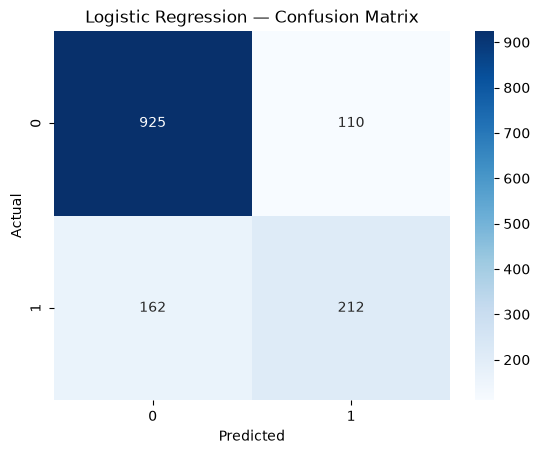

In [22]:
evaluate('Logistic Regression', lr, X_test_scaled, y_test)

--- Random Forest ---
Accuracy:  0.806
Recall:    0.535
Precision: 0.669
F1-Score:  0.594
ROC-AUC:   0.844


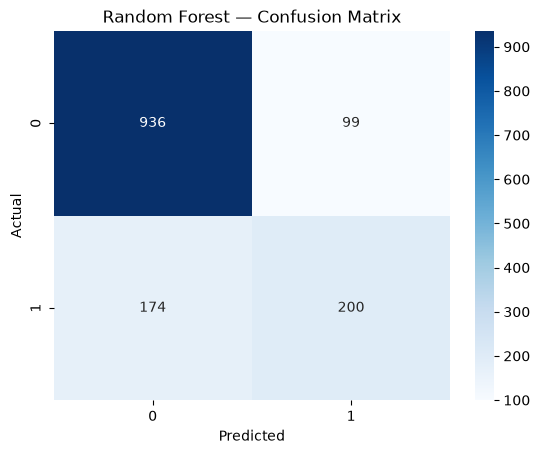

In [23]:
evaluate('Random Forest', rf, X_test, y_test)

--- Logistic Regression (Balanced) ---
Accuracy:  0.740
Recall:    0.786
Precision: 0.507
F1-Score:  0.616
ROC-AUC:   0.841


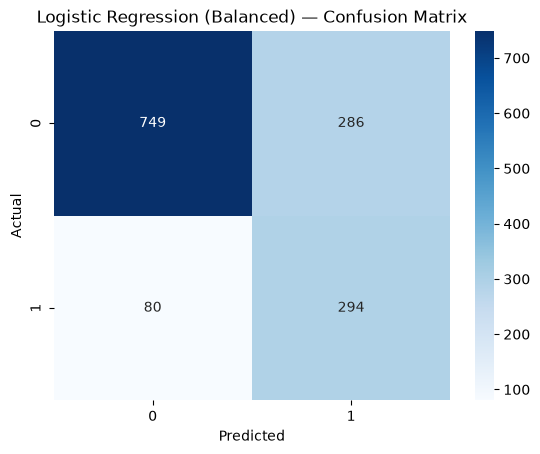

In [24]:
lr_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_balanced.fit(X_train_scaled, y_train)
evaluate('Logistic Regression (Balanced)', lr_balanced, X_test_scaled, y_test)

--- Random Forest (Balanced) ---
Accuracy:  0.759
Recall:    0.781
Precision: 0.532
F1-Score:  0.633
ROC-AUC:   0.841


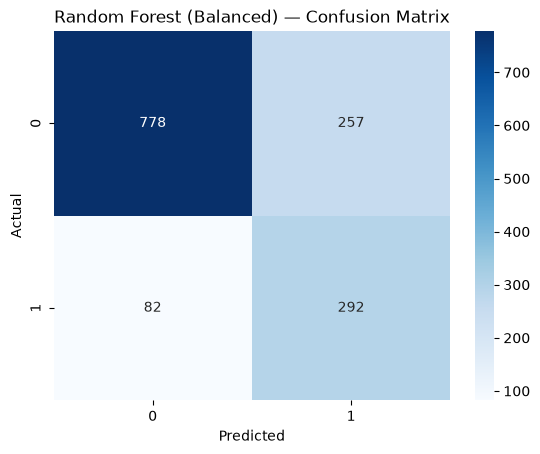

In [25]:
rf_balanced = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
rf_balanced.fit(X_train, y_train)
evaluate('Random Forest (Balanced)', rf_balanced, X_test, y_test)

In [26]:
import joblib

joblib.dump(rf_balanced, '../models/churn_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(X.columns.tolist(), '../models/model_columns.pkl')

print("Model saved!")

Model saved!


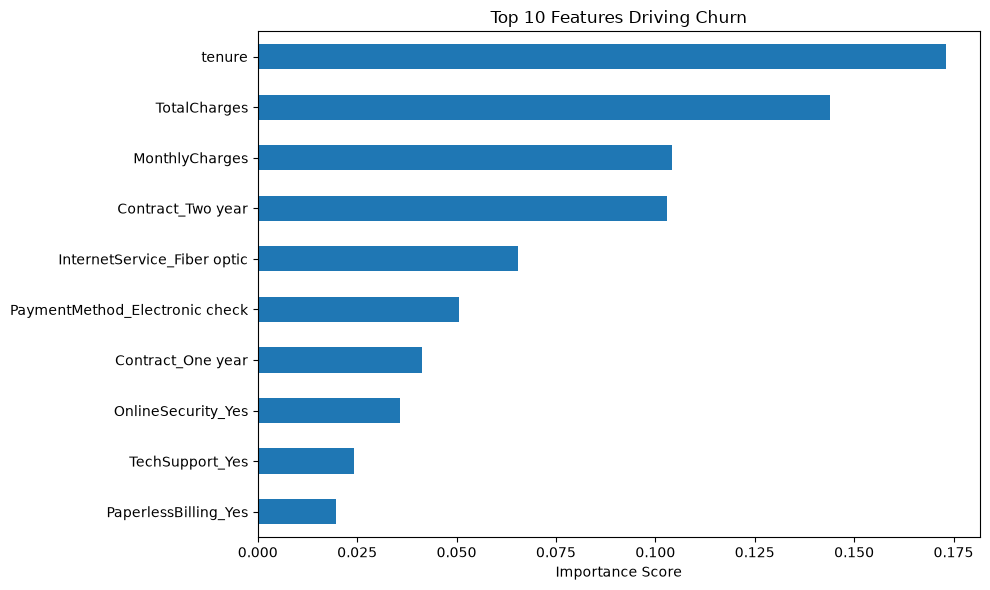

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(rf_balanced.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances.head(10).plot(kind='barh')
plt.title('Top 10 Features Driving Churn')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../models/feature_importance.png')  # saves it as an image for your slides
plt.show()

--- XGBoost (Balanced) ---
Accuracy:  0.756
Recall:    0.751
Precision: 0.528
F1-Score:  0.620
ROC-AUC:   0.831


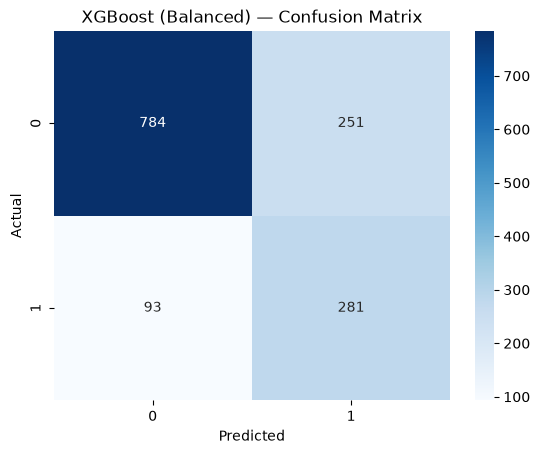

In [29]:
from xgboost import XGBClassifier

# XGBoost has its own way of handling imbalance: scale_pos_weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss', random_state=42
)
xgb.fit(X_train, y_train)
evaluate('XGBoost (Balanced)', xgb, X_test, y_test)

In [30]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Logistic Regression (Balanced)',
              'Random Forest (Balanced)', 'XGBoost (Balanced)'],
    'Accuracy': [0.807, 0.806, 0.740, 0.759, 0.756],
    'Recall': [0.567, 0.535, 0.786, 0.781, 0.751],
    'Precision': [0.658, 0.669, 0.507, 0.532, 0.528],
    'F1': [0.609, 0.594, 0.616, 0.633, 0.620],
    'ROC_AUC': [0.842, 0.844, 0.841, 0.841, 0.831]
})
comparison.to_csv('../models/model_comparison.csv', index=False)
comparison

,Model,Accuracy,Recall,Precision,F1,ROC_AUC
0,Logistic Regression,0.807,0.567,0.658,0.609,0.842
1,Random Forest,0.806,0.535,0.669,0.594,0.844
2,Logistic Regression (Balanced),0.740,0.786,0.507,0.616,0.841
3,Random Forest (Balanced),0.759,0.781,0.532,0.633,0.841
4,XGBoost (Balanced),0.756,0.751,0.528,0.620,0.831
